In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cvxpy as cp
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

sns.set(style="whitegrid")

In [7]:
df = pd.read_csv('Social_Network_Ads.csv')
print("Dataset loaded successfully.")
X = df[['Age', 'EstimatedSalary']].values
y = df['Purchased'].values

y = np.where(y == 0, -1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training Data Shape: {X_train_scaled.shape}")
print(f"Labels: {np.unique(y_train)}")

Dataset loaded successfully.
Training Data Shape: (300, 2)
Labels: [-1  1]


In [8]:

C = 1.0
n_samples, n_features = X_train_scaled.shape
w = cp.Variable(n_features)
b = cp.Variable()
xi = cp.Variable(n_samples)

objective = cp.Minimize(0.5 * cp.sum_squares(w) + C * cp.sum(xi))

constraints = [
    cp.multiply(y_train, (X_train_scaled @ w + b)) >= 1 - xi,
    xi >= 0
]
problem = cp.Problem(objective, constraints)
problem.solve()

w_opt = w.value
b_opt = b.value

print("Optimization Status:", problem.status)
print(f"Optimal w: {w_opt}")
print(f"Optimal b: {b_opt:.4f}")

Optimization Status: optimal
Optimal w: [1.37454416 0.88396769]
Optimal b: -0.8153


In [9]:
decision_values = X_test_scaled @ w_opt + b_opt

y_pred = np.sign(decision_values)

acc = accuracy_score(y_test, y_pred)
print(f"QP-SVM Custom Model Accuracy: {acc:.4f}")

QP-SVM Custom Model Accuracy: 0.8600


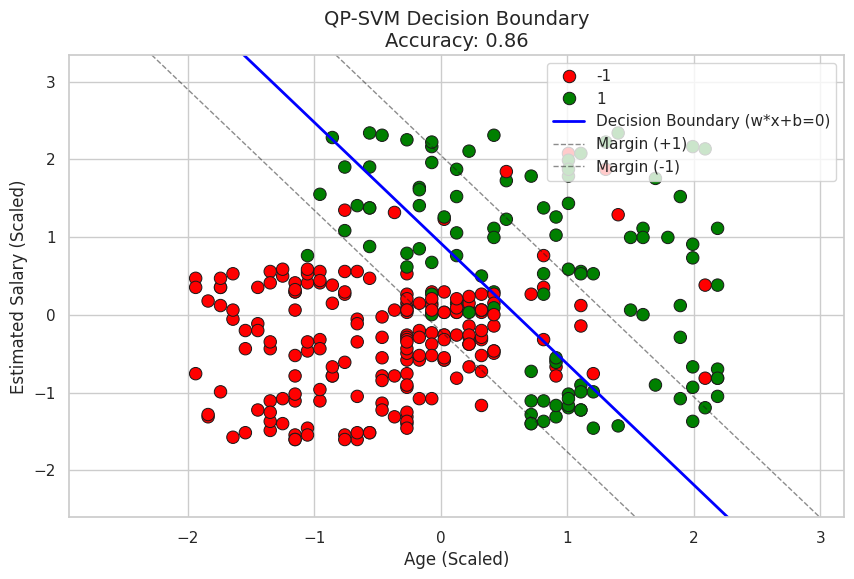

In [10]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=X_train_scaled[:, 0],
    y=X_train_scaled[:, 1],
    hue=y_train,
    palette={-1: 'red', 1: 'green'},
    edgecolor='k',
    s=80
)
x1_min, x1_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
x1_vals = np.linspace(x1_min, x1_max, 100)

w1, w2 = w_opt
x2_vals = -(w1 * x1_vals + b_opt) / w2

plt.plot(x1_vals, x2_vals, color='blue', linewidth=2,
         label='Decision Boundary (w*x+b=0)')
plt.plot(x1_vals, -(w1 * x1_vals + b_opt - 1) / w2, 'k--',
         linewidth=1, alpha=0.5, label='Margin (+1)')
plt.plot(x1_vals, -(w1 * x1_vals + b_opt + 1) / w2, 'k--',
         linewidth=1, alpha=0.5, label='Margin (-1)')

plt.title(f"QP-SVM Decision Boundary\nAccuracy: {acc:.2f}", fontsize=14)
plt.xlabel("Age (Scaled)")
plt.ylabel("Estimated Salary (Scaled)")
plt.legend()
plt.xlim(x1_min, x1_max)
plt.ylim(X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1)

plt.show()